In [ ]:
!gdown 1NwikiUU_Yzom-l4Kwy24Cn-bG46gMmG4

Downloading...
From (original): https://drive.google.com/uc?id=1NwikiUU_Yzom-l4Kwy24Cn-bG46gMmG4
From (redirected): https://drive.google.com/uc?id=1NwikiUU_Yzom-l4Kwy24Cn-bG46gMmG4&confirm=t&uuid=00521aee-19de-4a23-87e9-22982f048d9a
To: /content/creditcard.csv
100% 151M/151M [00:02<00:00, 50.5MB/s]


In [ ]:
!gdown 1GR3IwbvKNuiVXN5E5eMGyEQtT4pP7kCt

Downloading...
From: https://drive.google.com/uc?id=1GR3IwbvKNuiVXN5E5eMGyEQtT4pP7kCt
To: /content/Twitter_Data.csv
100% 20.9M/20.9M [00:00<00:00, 43.7MB/s]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
import pandas as pd

df = pd.read_csv('creditcard.csv')
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
dataset_arr = df.to_numpy()
X, y = dataset_arr[:, :-1].astype(np.float64), dataset_arr[:, -1].astype(np.uint8)

In [ ]:
intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((intercept, X), 1)
X_b

array([[ 1.00000000e+00,  0.00000000e+00, -1.35980713e+00, ...,
         1.33558377e-01, -2.10530535e-02,  1.49620000e+02],
       [ 1.00000000e+00,  0.00000000e+00,  1.19185711e+00, ...,
        -8.98309914e-03,  1.47241692e-02,  2.69000000e+00],
       [ 1.00000000e+00,  1.00000000e+00, -1.35835406e+00, ...,
        -5.53527940e-02, -5.97518406e-02,  3.78660000e+02],
       ...,
       [ 1.00000000e+00,  1.72788000e+05,  1.91956501e+00, ...,
         4.45477214e-03, -2.65608286e-02,  6.78800000e+01],
       [ 1.00000000e+00,  1.72788000e+05, -2.40440050e-01, ...,
         1.08820735e-01,  1.04532821e-01,  1.00000000e+01],
       [ 1.00000000e+00,  1.72792000e+05, -5.33412522e-01, ...,
        -2.41530880e-03,  1.36489143e-02,  2.17000000e+02]])

In [ ]:
n_classes = np.unique(y, axis =0).shape[0]
n_samples = y.shape[0]

y_encoded = np.array([np.zeros( n_classes ) for _ in range( n_samples )])
y_encoded[np.arange( n_samples ) , y] = 1

In [ ]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_b, y_encoded,
    test_size = val_size,
    random_state = random_state,
    shuffle = is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size = test_size,
    random_state = random_state,
    shuffle = is_shuffle
)

In [ ]:
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

In [ ]:
def predict (X, theta ) :
    dot_product = np.dot(X, theta)
    y_hat = softmax(dot_product)

    return y_hat

def softmax(z):
    exp_z = np.exp(z)
    return exp_z/exp_z.sum(axis=1)[: , None]

def compute_loss(y_hat , y) :
    n = y.size

    return (-1/n) * np.sum(y * np.log(y_hat))

def compute_gradient(X, y, y_hat ) :
    return np.dot( X.T, (y_hat - y) )/y.size

def update_theta(theta, gradient, lr):
    return theta - lr*gradient

def compute_accuracy(X, y, theta):
    y_hat = predict(X, theta).round()
    acc = (np.argmax(y_hat , axis=1) == np.argmax(y, axis=1)).mean()

    return acc

In [ ]:
lr = 0.1
epochs = 30
batch_size = 1024
np.random.seed(random_state)
theta = np.random.uniform(
    size = (X_train.shape[1], n_classes)
)

In [ ]:
train_accs = []
train_losses = []
val_accs = []
val_losses = []
for epoch in range( epochs ):
    train_batch_losses = []
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size ) :
        X_i = X_train [i:i+ batch_size ]
        y_i = y_train [i:i+ batch_size ]

        y_hat = predict(X_i, theta )

        train_loss = compute_loss(y_hat, y_i )

        gradient = compute_gradient(X_i, y_i, y_hat )

        theta = update_theta(theta, gradient, lr)


        train_batch_losses.append( train_loss )

        train_acc = compute_accuracy( X_train, y_train, theta )
        train_batch_accs.append( train_acc )

        y_val_hat = predict(X_val, theta )
        val_loss = compute_loss( y_val_hat, y_val )
        val_batch_losses.append( val_loss )

        val_acc = compute_accuracy(X_val, y_val, theta )
        val_batch_accs.append( val_acc )

    train_batch_loss = sum( train_batch_losses ) / len(train_batch_losses)
    val_batch_loss = sum( val_batch_losses ) / len( val_batch_losses )
    train_batch_acc = sum( train_batch_accs ) / len( train_batch_accs )
    val_batch_acc = sum( val_batch_accs ) / len( val_batch_accs )

    train_losses.append( train_batch_loss )
    val_losses.append( val_batch_loss )
    train_accs.append( train_batch_acc )
    val_accs.append( val_batch_acc )

    print(f'\n EPOCH { epoch + 1}:\t Training loss : { train_batch_loss:.3f}\t Validation loss : { val_batch_loss:.3f}')


 EPOCH 1:	 Training loss : 0.092	 Validation loss : 0.089

 EPOCH 2:	 Training loss : 0.019	 Validation loss : 0.018

 EPOCH 3:	 Training loss : 0.012	 Validation loss : 0.011

 EPOCH 4:	 Training loss : 0.009	 Validation loss : 0.008

 EPOCH 5:	 Training loss : 0.007	 Validation loss : 0.007

 EPOCH 6:	 Training loss : 0.006	 Validation loss : 0.006

 EPOCH 7:	 Training loss : 0.006	 Validation loss : 0.005

 EPOCH 8:	 Training loss : 0.005	 Validation loss : 0.005

 EPOCH 9:	 Training loss : 0.005	 Validation loss : 0.004

 EPOCH 10:	 Training loss : 0.004	 Validation loss : 0.004

 EPOCH 11:	 Training loss : 0.004	 Validation loss : 0.004

 EPOCH 12:	 Training loss : 0.004	 Validation loss : 0.004

 EPOCH 13:	 Training loss : 0.004	 Validation loss : 0.003

 EPOCH 14:	 Training loss : 0.004	 Validation loss : 0.003

 EPOCH 15:	 Training loss : 0.004	 Validation loss : 0.003

 EPOCH 16:	 Training loss : 0.003	 Validation loss : 0.003

 EPOCH 17:	 Training loss : 0.003	 Validation lo

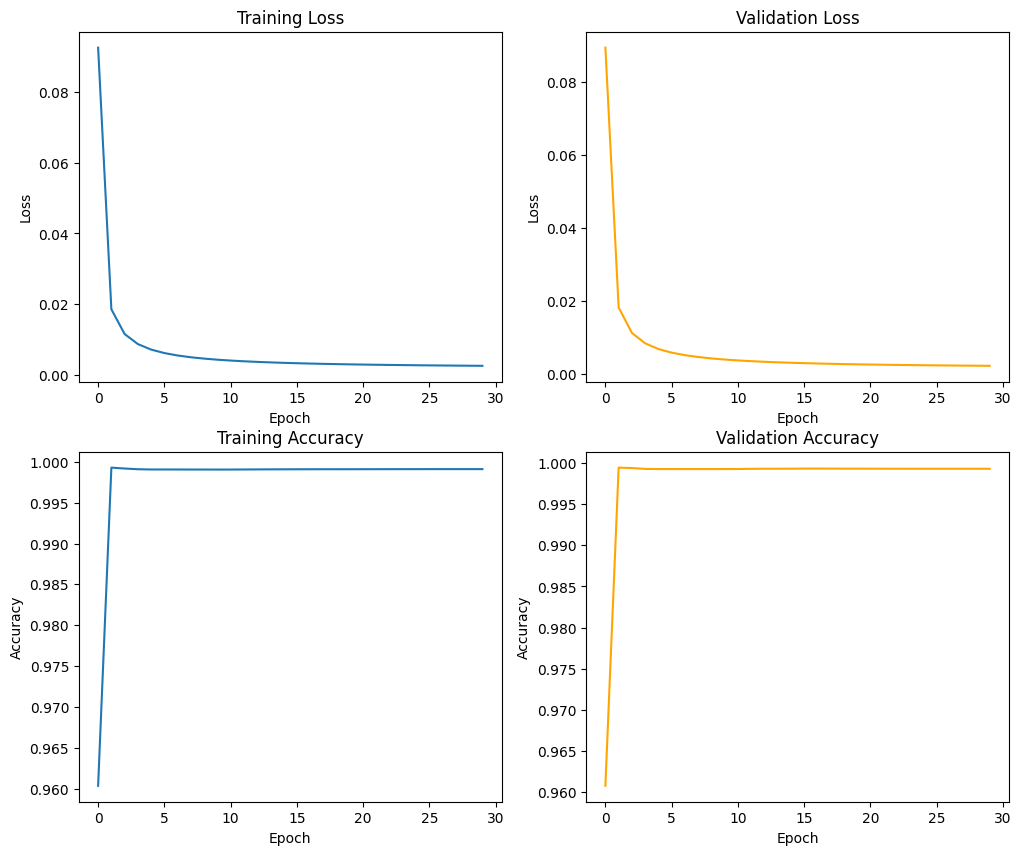

In [ ]:
fig, ax = plt.subplots(2, 2, figsize =(12, 10) )
ax[0, 0].plot( train_losses )
ax[0, 0].set( xlabel ='Epoch', ylabel ='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot( val_losses,'orange')
ax[0, 1].set( xlabel ='Epoch', ylabel ='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot( train_accs )
ax[1, 0].set( xlabel ='Epoch', ylabel ='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot( val_accs,'orange')
ax[1, 1].set( xlabel ='Epoch', ylabel ='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()

In [ ]:
val_set_acc = compute_accuracy (X_val, y_val, theta )
test_set_acc = compute_accuracy ( X_test, y_test, theta )
print('Evaluation on validation and test set :')
print(f'Accuracy : { val_set_acc }')
print(f'Accuracy : { test_set_acc }')

Evaluation on validation and test set :
Accuracy : 0.9993153330290369
Accuracy : 0.9992626663389628


In [ ]:
import re
import nltk

nltk.download('stopwords')
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df = pd.read_csv('Twitter_Data.csv')
print(df.head())

                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0


In [ ]:
df = df.dropna()

In [ ]:
df.head(5)

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [ ]:
def text_normalize( text ) :
    text = text.lower()

    # Retweet old acronym "RT" removal
    text = re.sub(r'^RT[\s]+', '', text )

    # Hyperlinks removal
    text = re.sub(r'https?:\/\/.*[\r\n]* ', '', text )

    # Hashtags removal
    text = re.sub(r'#', '', text )

    # Punctuation removal
    text = re.sub(r'[^\w\s]', '', text )

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words ]
    text = ' '.join(words)

    # Stemming
    stemmer = SnowballStemmer('english')
    words = text.split()
    words = [stemmer.stem(word) for word in words]
    text = ' '.join(words)

    return text

In [ ]:
#apply text normalize for x
df['clean_text'] = df['clean_text'].apply(text_normalize)

In [ ]:
df.head(5)

,clean_text,category
0,modi promis minimum govern maximum govern expe...,-1.0
1,talk nonsens continu drama vote modi,0.0
2,say vote modi welcom bjp told rahul main campa...,1.0
3,ask support prefix chowkidar name modi great s...,1.0
4,answer among power world leader today trump pu...,1.0


In [ ]:
vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(df['clean_text']).toarray()

In [ ]:
intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((intercept, X), 1)
X_b

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [ ]:
n_classes = df['category'].nunique()
n_samples = df['category'].size

y = df['category'].to_numpy() + 1
y = y.astype(np.uint8)
y_encoded = np.array([np.zeros(n_classes) for _ in range(n_samples)])
y_encoded[np.arange(n_samples) , y] = 1

In [ ]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_b, y_encoded,
    test_size = val_size,
    random_state = random_state,
    shuffle = is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size = test_size,
    random_state = random_state,
    shuffle = is_shuffle
)

In [ ]:
lr = 0.1
epochs = 200
batch_size = n_samples
np.random.seed(random_state)
theta = np.random.uniform(
    size = (X_train.shape[1], n_classes)
)

In [ ]:
train_accs = []
train_losses = []
val_accs = []
val_losses = []
for epoch in range( epochs ):
    train_batch_losses = []
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size ) :
        X_i = X_train [i:i+ batch_size ]
        y_i = y_train [i:i+ batch_size ]

        y_hat = predict(X_i, theta )

        train_loss = compute_loss(y_hat, y_i )

        gradient = compute_gradient(X_i, y_i, y_hat )

        theta = update_theta(theta, gradient, lr)


        train_batch_losses.append( train_loss )

        train_acc = compute_accuracy( X_train, y_train, theta )
        train_batch_accs.append( train_acc )

        y_val_hat = predict(X_val, theta )
        val_loss = compute_loss( y_val_hat, y_val )
        val_batch_losses.append( val_loss )

        val_acc = compute_accuracy(X_val, y_val, theta )
        val_batch_accs.append( val_acc )

    train_batch_loss = sum( train_batch_losses ) / len(train_batch_losses)
    val_batch_loss = sum( val_batch_losses ) / len( val_batch_losses )
    train_batch_acc = sum( train_batch_accs ) / len( train_batch_accs )
    val_batch_acc = sum( val_batch_accs ) / len( val_batch_accs )

    train_losses.append( train_batch_loss )
    val_losses.append( val_batch_loss )
    train_accs.append( train_batch_acc )
    val_accs.append( val_batch_acc )

    print(f'\n EPOCH { epoch + 1}:\t Training loss : { train_batch_loss:.3f}\t Validation loss : { val_batch_loss:.3f}')


 EPOCH 1:	 Training loss : 0.384	 Validation loss : 0.384

 EPOCH 2:	 Training loss : 0.384	 Validation loss : 0.384

 EPOCH 3:	 Training loss : 0.384	 Validation loss : 0.383

 EPOCH 4:	 Training loss : 0.383	 Validation loss : 0.383

 EPOCH 5:	 Training loss : 0.383	 Validation loss : 0.383

 EPOCH 6:	 Training loss : 0.382	 Validation loss : 0.382

 EPOCH 7:	 Training loss : 0.382	 Validation loss : 0.382

 EPOCH 8:	 Training loss : 0.382	 Validation loss : 0.382

 EPOCH 9:	 Training loss : 0.382	 Validation loss : 0.381

 EPOCH 10:	 Training loss : 0.381	 Validation loss : 0.381

 EPOCH 11:	 Training loss : 0.381	 Validation loss : 0.381

 EPOCH 12:	 Training loss : 0.381	 Validation loss : 0.380

 EPOCH 13:	 Training loss : 0.380	 Validation loss : 0.380

 EPOCH 14:	 Training loss : 0.380	 Validation loss : 0.380

 EPOCH 15:	 Training loss : 0.380	 Validation loss : 0.380

 EPOCH 16:	 Training loss : 0.380	 Validation loss : 0.379

 EPOCH 17:	 Training loss : 0.379	 Validation lo

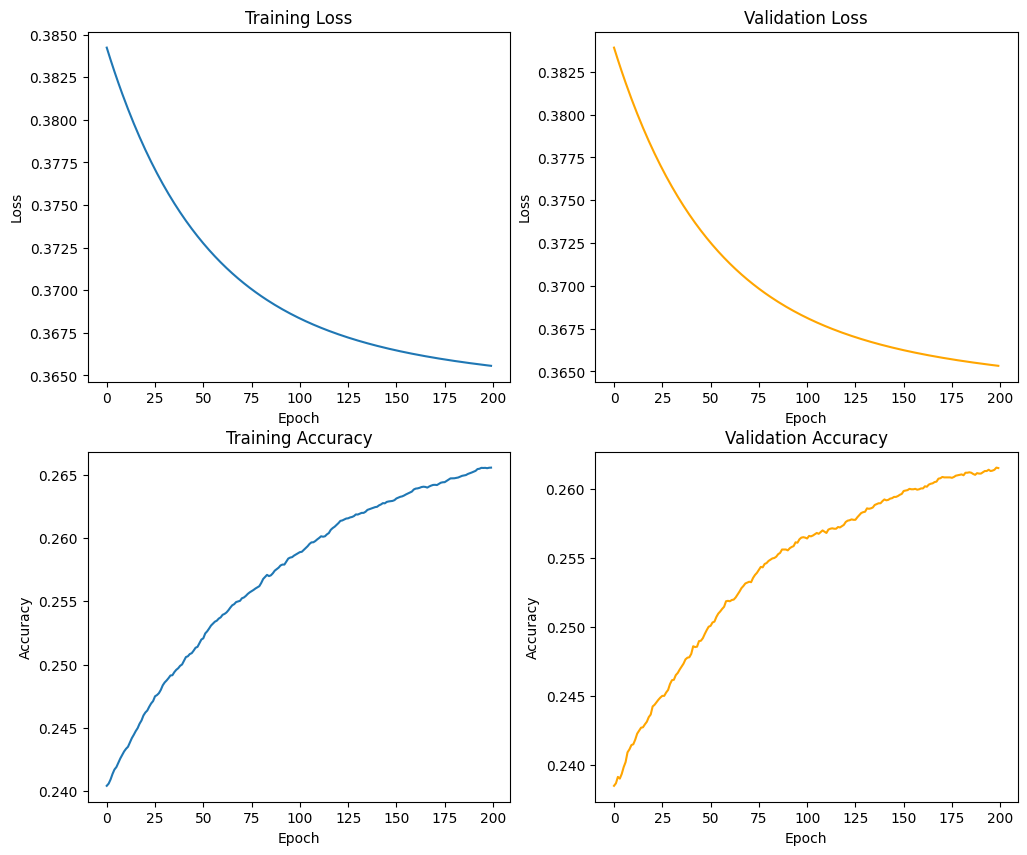

In [ ]:
fig, ax = plt.subplots(2, 2, figsize =(12, 10) )
ax[0, 0].plot( train_losses )
ax[0, 0].set( xlabel ='Epoch', ylabel ='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot( val_losses,'orange')
ax[0, 1].set( xlabel ='Epoch', ylabel ='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot( train_accs )
ax[1, 0].set( xlabel ='Epoch', ylabel ='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot( val_accs,'orange')
ax[1, 1].set( xlabel ='Epoch', ylabel ='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()

In [ ]:
val_set_acc = compute_accuracy (X_val, y_val, theta )
test_set_acc = compute_accuracy ( X_test, y_test, theta )
print('Evaluation on validation and test set :')
print(f'Accuracy : { val_set_acc }')
print(f'Accuracy : { test_set_acc }')

Evaluation on validation and test set :
Accuracy : 0.26148984475670367
Accuracy : 0.2574093391421734


In [ ]:
import bisect

max_beauties = [(10, 5), (20, 15), (30, 25)]
q = 25
# Use bisect.bisect_right after importing the module
print(bisect.bisect_right(max_beauties, (25, float('inf'))))

2
